In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/eda-titanic/tested.csv


In [4]:
from IPython.display import Image, display
display(Image(filename="/kaggle/input/iiiiiiiiimg/3bB2UnWTUkslTngQMkwRZbO3qdYkhD.jpg"))


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")


In [6]:
df = pd.read_csv("/kaggle/input/eda-titanic/tested.csv")  # change to actual file name


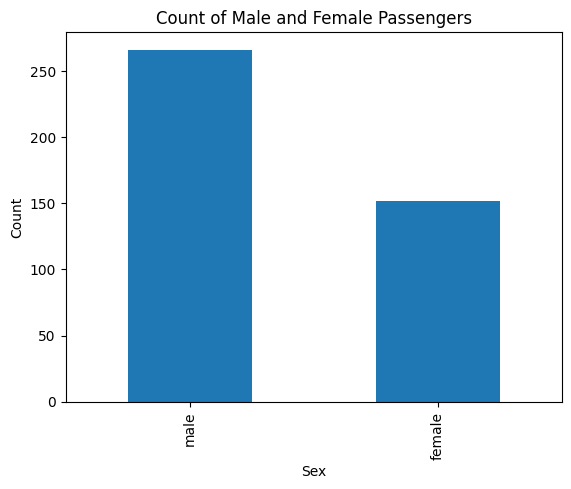

In [7]:
# 1. Plot the count of male and female passengers
plt.figure()
df['Sex'].value_counts().plot(kind='bar')
plt.title("Count of Male and Female Passengers")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

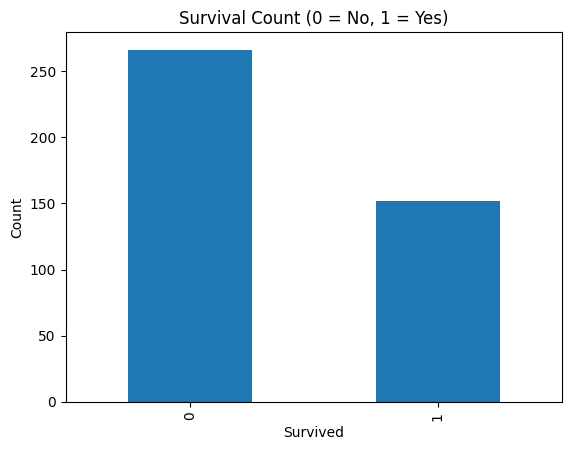

In [8]:
# 2. Plot the number of passengers who survived vs who didn’t
plt.figure()
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

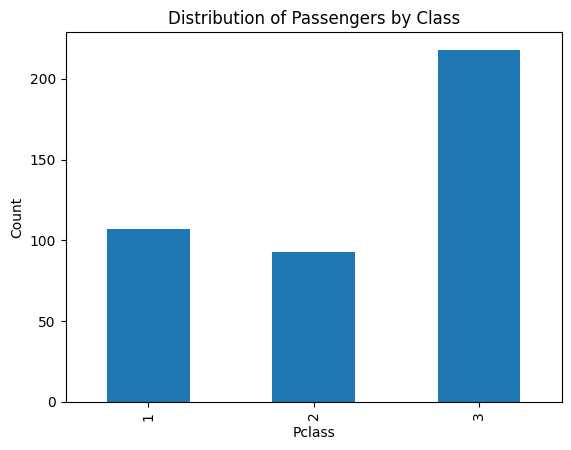

In [9]:
# 3. Show the distribution of passengers by class (Pclass)
plt.figure()
df['Pclass'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Passengers by Class")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

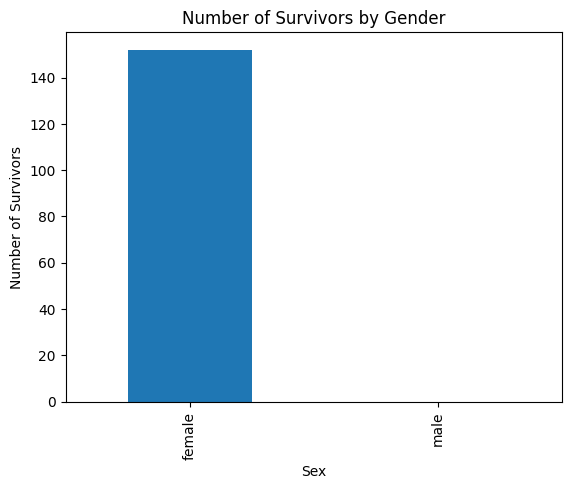

In [10]:
# 4. Visualize the number of survivors by gender
plt.figure()
df.groupby('Sex')['Survived'].sum().plot(kind='bar')
plt.title("Number of Survivors by Gender")
plt.xlabel("Sex")
plt.ylabel("Number of Survivors")
plt.show()

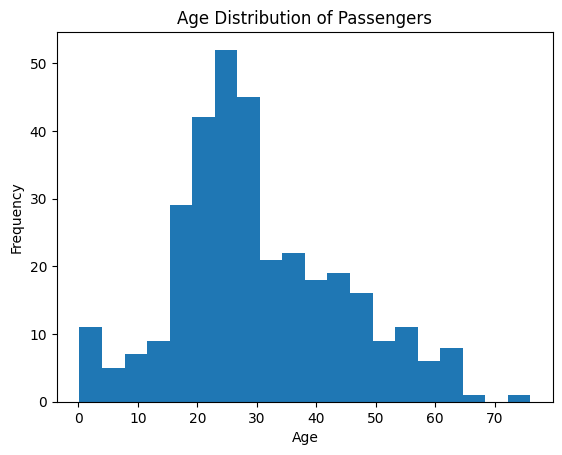

In [11]:
# 5. Show a histogram of passengers’ ages
plt.figure()
df['Age'].dropna().plot(kind='hist', bins=20)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

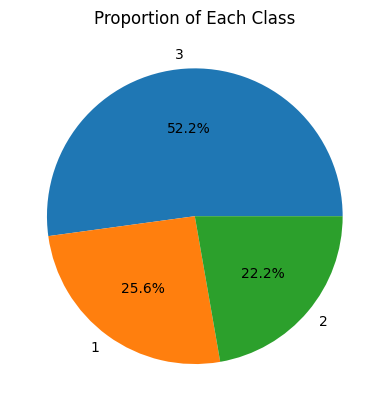

In [12]:
# 6. Plot a pie chart showing the proportion of each class
plt.figure()
df['Pclass'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Proportion of Each Class")
plt.ylabel("")
plt.show()

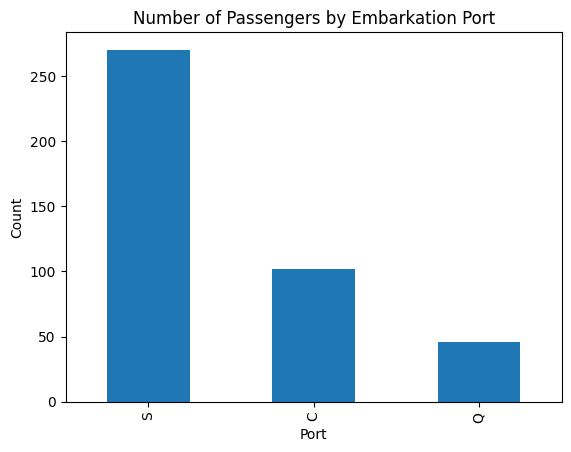

In [13]:
# 7. Plot a bar chart of number of passengers in each embarkation port
plt.figure()
df['Embarked'].value_counts().plot(kind='bar')
plt.title("Number of Passengers by Embarkation Port")
plt.xlabel("Port")
plt.ylabel("Count")
plt.show()


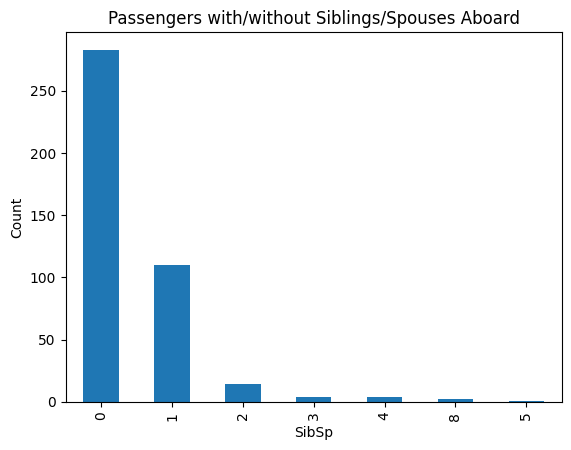

In [14]:
# 8. Show the count of passengers with/without siblings/spouses aboard
plt.figure()
df['SibSp'].value_counts().plot(kind='bar')
plt.title("Passengers with/without Siblings/Spouses Aboard")
plt.xlabel("SibSp")
plt.ylabel("Count")
plt.show()

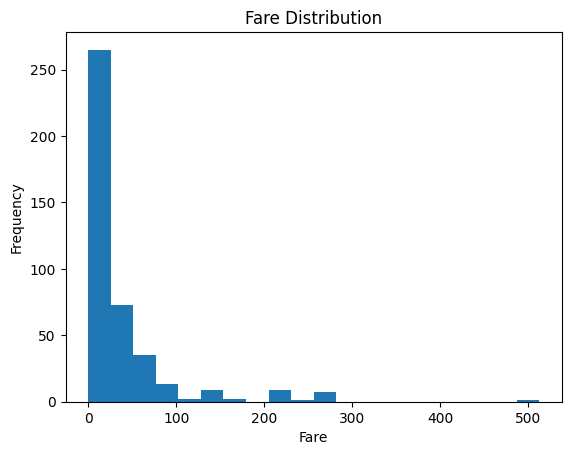

In [15]:
# 9. Create a histogram for Fare column
plt.figure()
df['Fare'].plot(kind='hist', bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


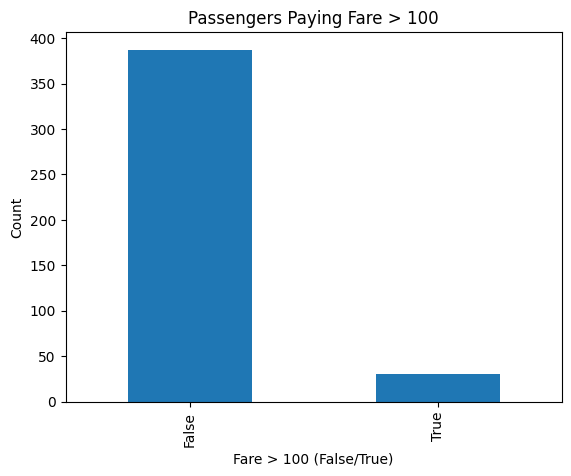

In [17]:
# 10. Plot the number of passengers who paid fare above 100
plt.figure()
(df['Fare'] > 100).value_counts().plot(kind='bar')
plt.title("Passengers Paying Fare > 100")
plt.xlabel("Fare > 100 (False/True)")
plt.ylabel("Count")
plt.show()

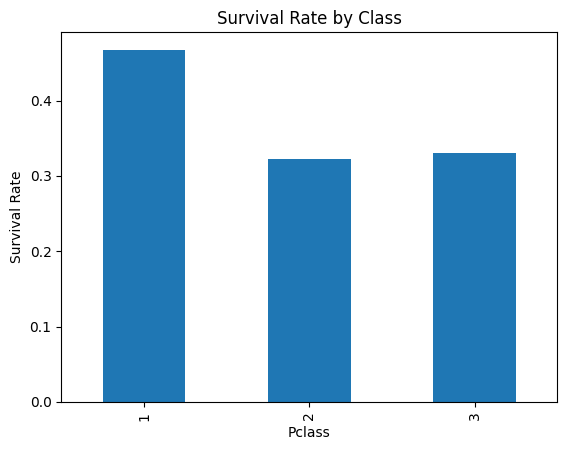

In [18]:
# 11. Show the survival rate by class (Pclass)
plt.figure()
(df.groupby('Pclass')['Survived'].mean()).plot(kind='bar')
plt.title("Survival Rate by Class")
plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.show()

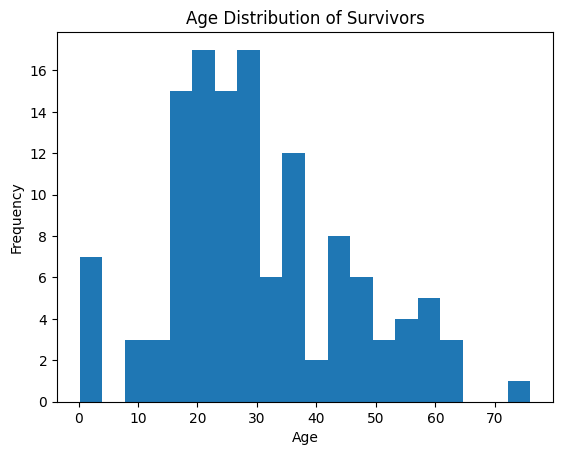

In [19]:
# 12. Plot age distribution of survivors only
plt.figure()
df[df['Survived'] == 1]['Age'].dropna().plot(kind='hist', bins=20)
plt.title("Age Distribution of Survivors")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


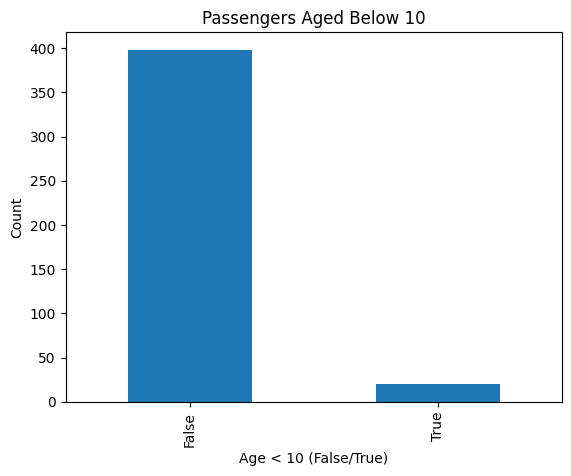

In [20]:
# 13. Visualize number of passengers aged below 10
plt.figure()
(df['Age'] < 10).value_counts().plot(kind='bar')
plt.title("Passengers Aged Below 10")
plt.xlabel("Age < 10 (False/True)")
plt.ylabel("Count")
plt.show()

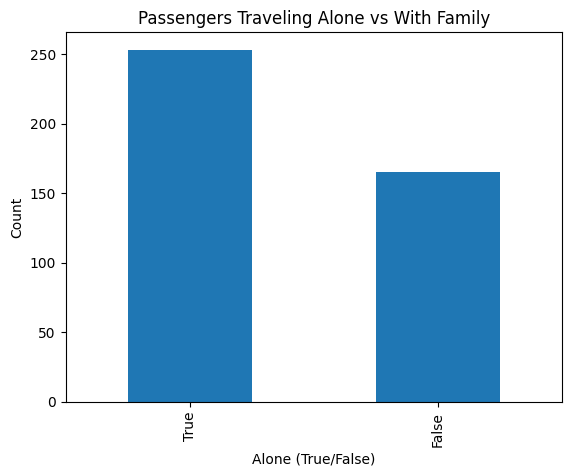

In [21]:
# 14. Show count of passengers who traveled alone vs with family
plt.figure()
(df['SibSp'] + df['Parch'] == 0).value_counts().plot(kind='bar')
plt.title("Passengers Traveling Alone vs With Family")
plt.xlabel("Alone (True/False)")
plt.ylabel("Count")
plt.show()


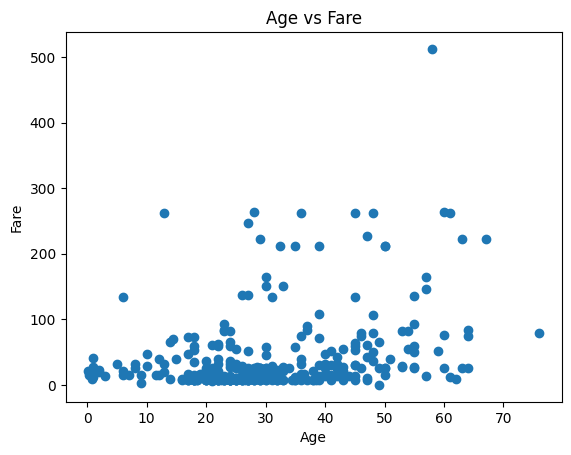

In [22]:
# 15. Create a scatter plot of Age vs Fare
plt.figure()
plt.scatter(df['Age'], df['Fare'])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

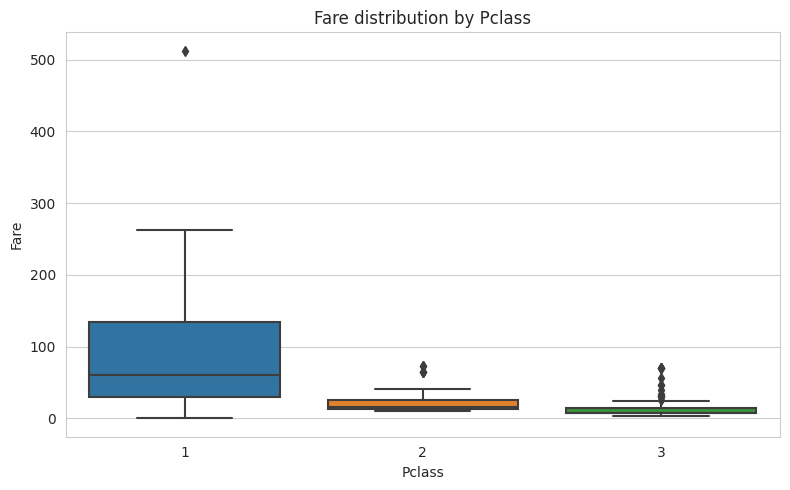

In [27]:
# ---------- 16. Boxplot showing Fare distribution by Pclass ----------
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare distribution by Pclass")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

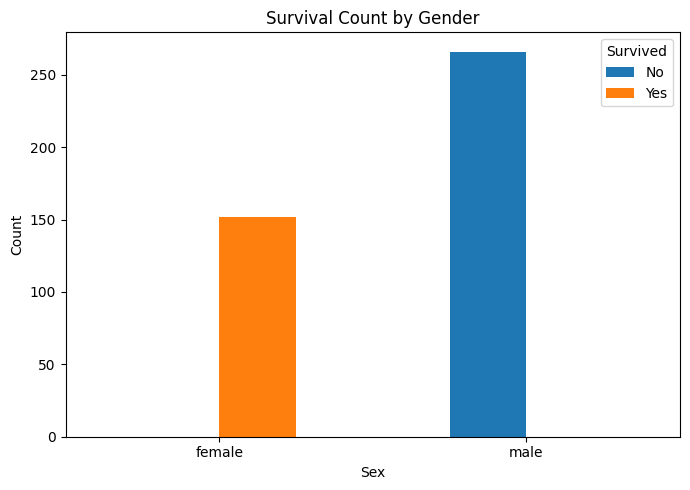

In [25]:
# ---------- 17. Plot survival count for each gender using a grouped bar chart ----------
ct = pd.crosstab(df['Sex'], df['Survived'])
ct.plot(kind='bar', figsize=(7,5))
plt.title("Survival Count by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No','Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

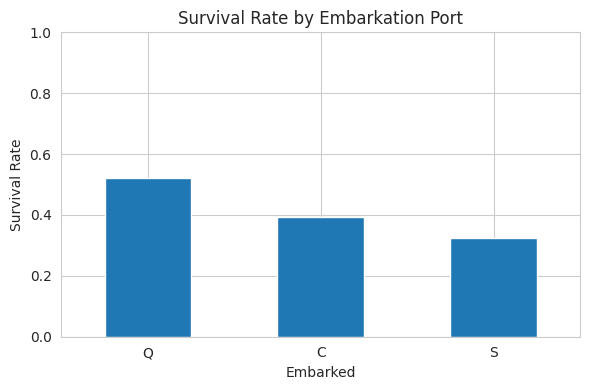

In [29]:
# ---------- 18. Compare survival rate across different embarkation ports ----------
embark = df.dropna(subset=['Embarked']).groupby('Embarked')['Survived'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
embark.plot(kind='bar')
plt.title("Survival Rate by Embarkation Port")
plt.ylabel("Survival Rate")
plt.ylim(0,1)
plt.xlabel("Embarked")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

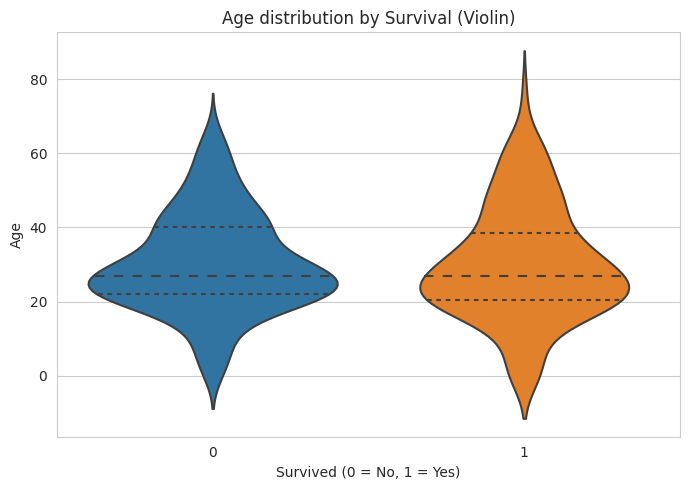

In [30]:
# ---------- 19. Violin plot of Age by Survived ----------
plt.figure(figsize=(7,5))
sns.violinplot(x='Survived', y='Age', data=df[df['Age'].notna()], inner='quartile')
plt.title("Age distribution by Survival (Violin)")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3544: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the mark

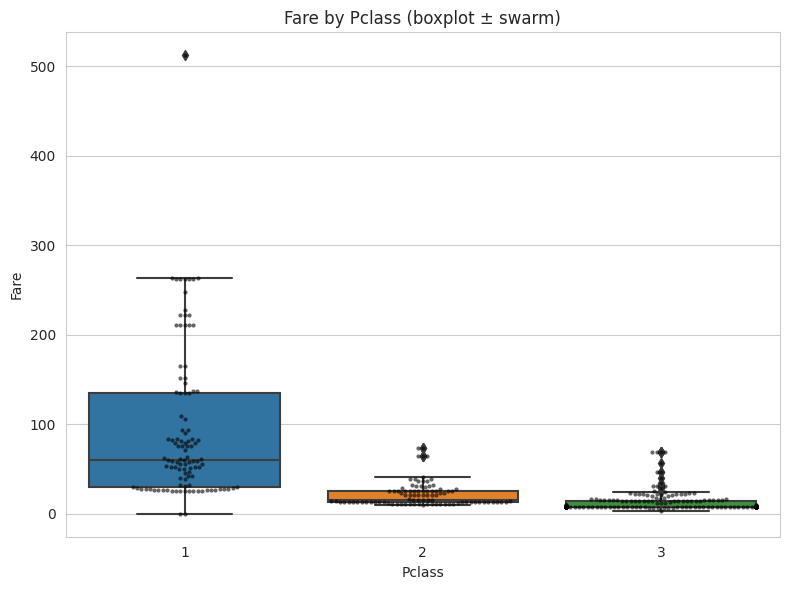

In [31]:
# ---------- 20. Visualize how Fare varies with Pclass using boxplot (optionally swarmplot) ----------
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y='Fare', data=df)
# Overlay a small swarmplot (comment out if too slow/overplotted)
try:
    sns.swarmplot(x='Pclass', y='Fare', data=df, color='k', size=3, alpha=0.6)
except Exception:
    pass
plt.title("Fare by Pclass (boxplot ± swarm)")
plt.tight_layout()
plt.show()

Passengers with Fare > 100: 31


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


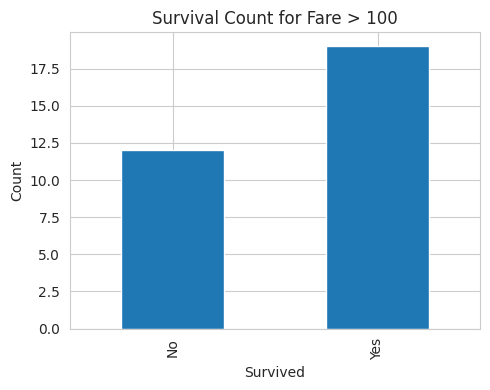

Survival rate among Fare>100 passengers: 61.29%


In [32]:
# ---------- 21. Survival rate among passengers who paid high fares (>100) ----------
highfare = df[df['Fare'] > 100]
print("Passengers with Fare > 100:", len(highfare))
plt.figure(figsize=(5,4))
highfare['Survived'].value_counts().sort_index().plot(kind='bar')
plt.title("Survival Count for Fare > 100")
plt.xticks([0,1], ['No','Yes'])
plt.ylabel("Count")
plt.tight_layout()
plt.show()

rate_high = highfare['Survived'].mean() if len(highfare) else np.nan
print(f"Survival rate among Fare>100 passengers: {rate_high:.2%}" if not np.isnan(rate_high) else "No high-fare passengers found.")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


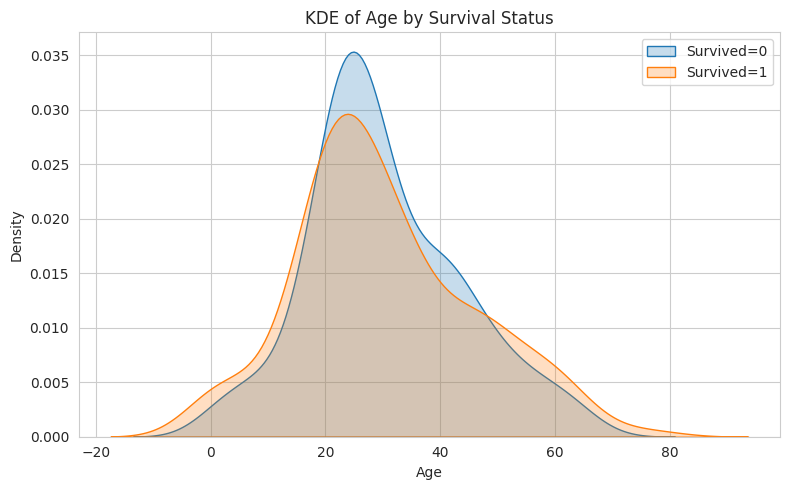

In [33]:
# ---------- 22. KDE plot for Age distribution by survival status ----------
plt.figure(figsize=(8,5))
for s in sorted(df['Survived'].dropna().unique()):
    sns.kdeplot(df.loc[df['Survived']==s, 'Age'].dropna(), fill=True, label=f"Survived={s}", common_norm=False)
plt.title("KDE of Age by Survival Status")
plt.xlabel("Age")
plt.legend()
plt.tight_layout()
plt.show()

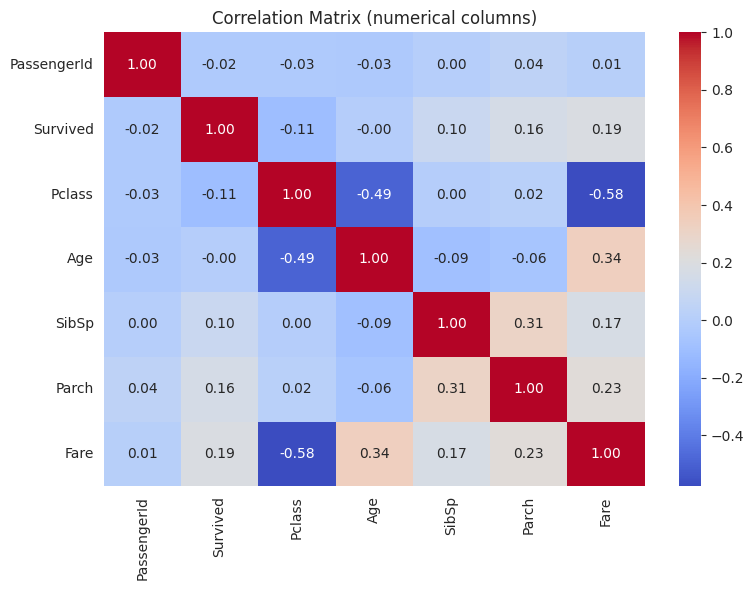

In [34]:
# ---------- 23. Heatmap showing correlation between numerical columns ----------
num = df.select_dtypes(include=np.number)
corr = num.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=False)
plt.title("Correlation Matrix (numerical columns)")
plt.tight_layout()
plt.show()

In [38]:
df['HasSibSp'] = df['SibSp'] > 0


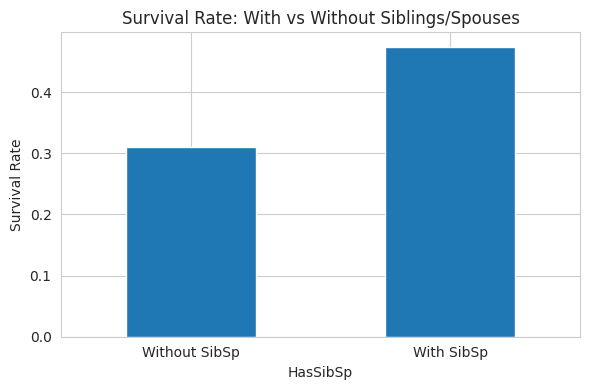

<Figure size 600x400 with 0 Axes>

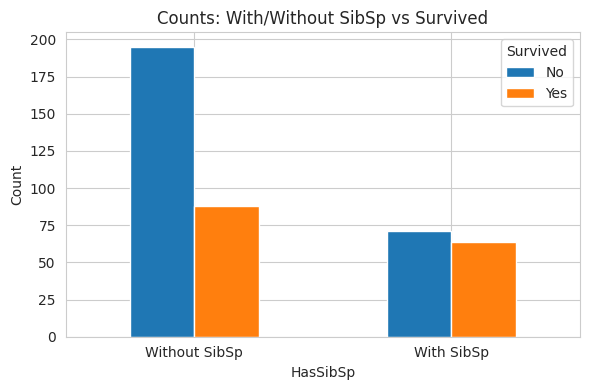

In [39]:
# ---------- 24. Compare survival among passengers with and without siblings/spouses ----------
surv_by_sib = df.groupby('HasSibSp')['Survived'].mean()
plt.figure(figsize=(6,4))
surv_by_sib.plot(kind='bar')
plt.xticks([0,1], ['Without SibSp','With SibSp'], rotation=0)
plt.ylabel("Survival Rate")
plt.title("Survival Rate: With vs Without Siblings/Spouses")
plt.tight_layout()
plt.show()

# Also show raw counts
plt.figure(figsize=(6,4))
pd.crosstab(df['HasSibSp'], df['Survived']).plot(kind='bar', stacked=False, figsize=(6,4))
plt.title("Counts: With/Without SibSp vs Survived")
plt.xlabel("HasSibSp")
plt.xticks([0,1], ['Without SibSp','With SibSp'], rotation=0)
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No','Yes'])
plt.tight_layout()
plt.show()

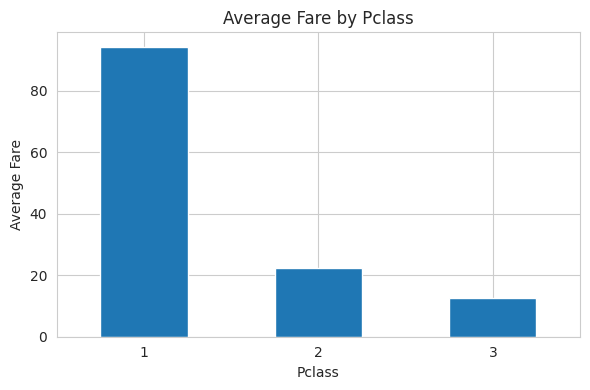

In [40]:
# ---------- 25. Average fare paid by each Pclass ----------
avg_fare = df.groupby('Pclass')['Fare'].mean().sort_index()
plt.figure(figsize=(6,4))
avg_fare.plot(kind='bar')
plt.title("Average Fare by Pclass")
plt.xlabel("Pclass")
plt.ylabel("Average Fare")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

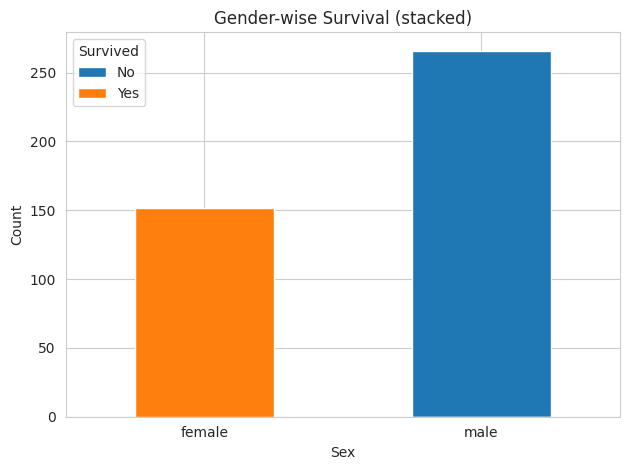

In [41]:
# ---------- 26. Stacked bar chart showing gender-wise survival ----------
plt.figure(figsize=(7,5))
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', stacked=True)
plt.title("Gender-wise Survival (stacked)")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title='Survived', labels=['No','Yes'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_36/3070504506.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agebin_counts = df.dropna(subset=['AgeBin']).groupby(['AgeBin','Survived']).size().unstack(fill_value=0)


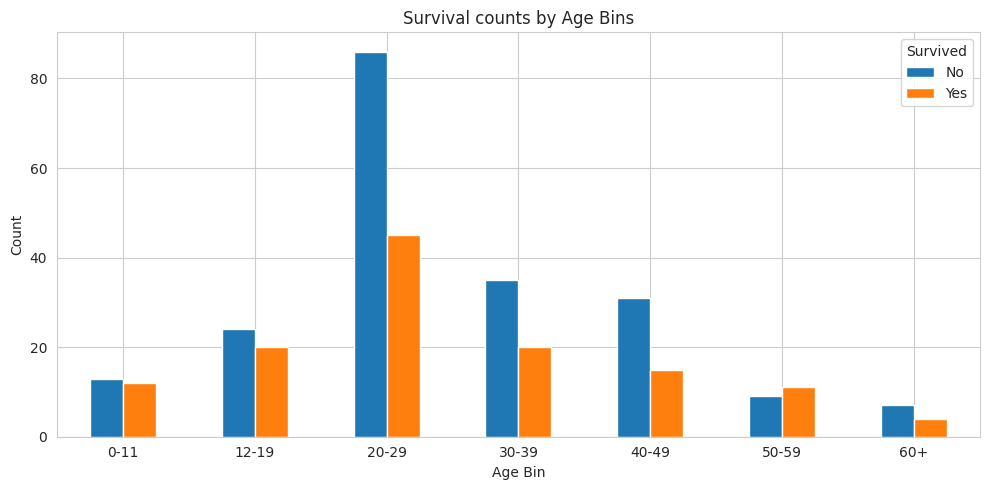

In [42]:
# ---------- 27. Group passengers into age bins and plot survival counts ----------
bins = [0, 12, 20, 30, 40, 50, 60, 80]
labels = ["0-11","12-19","20-29","30-39","40-49","50-59","60+"]
df['AgeBin'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
agebin_counts = df.dropna(subset=['AgeBin']).groupby(['AgeBin','Survived']).size().unstack(fill_value=0)
agebin_counts.plot(kind='bar', figsize=(10,5))
plt.title("Survival counts by Age Bins")
plt.xlabel("Age Bin")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title='Survived', labels=['No','Yes'])
plt.tight_layout()
plt.show()

In [45]:
df['FamilySize'] = df['SibSp'] + df['Parch']


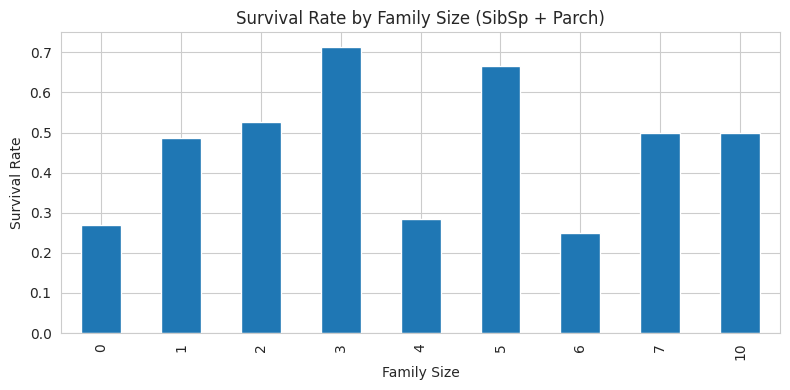

<Figure size 1000x500 with 0 Axes>

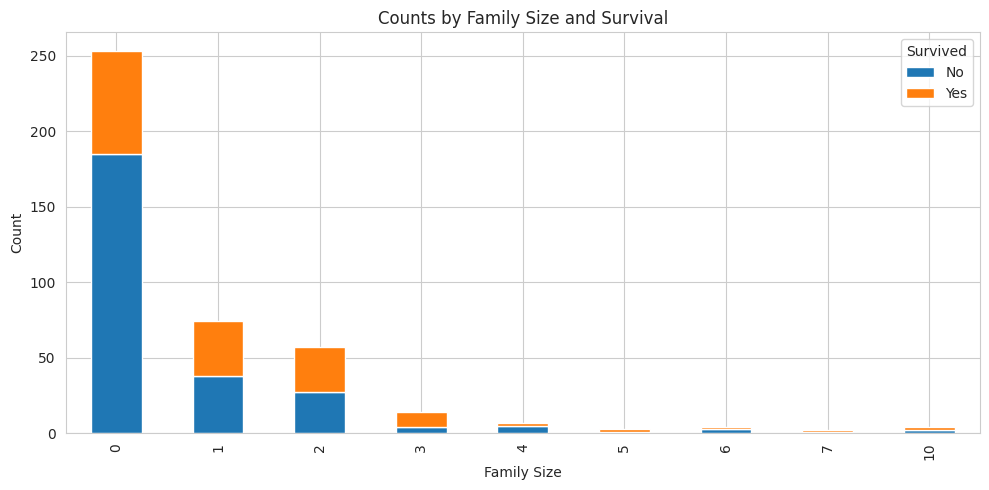

In [46]:
# ---------- 28. Visualize survival based on family size (SibSp + Parch) ----------
# Survival rate by family size
fs_rate = df.groupby('FamilySize')['Survived'].mean()
plt.figure(figsize=(8,4))
fs_rate.plot(kind='bar')
plt.title("Survival Rate by Family Size (SibSp + Parch)")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

# Counts (stacked) by family size
fs_counts = df.groupby('FamilySize')['Survived'].value_counts().unstack(fill_value=0)
plt.figure(figsize=(10,5))
fs_counts.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Counts by Family Size and Survival")
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.legend(title='Survived', labels=['No','Yes'])
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


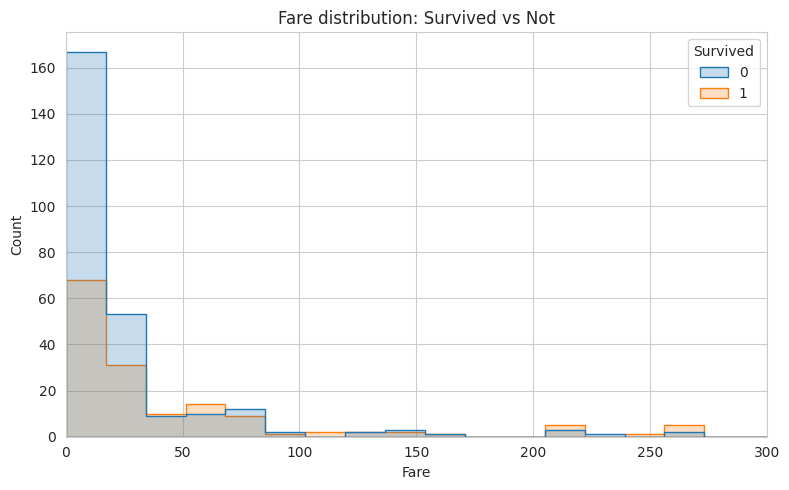

In [50]:
# ---------- 29. Histogram comparing Fare distribution of survivors vs non-survivors ----------
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Fare', hue='Survived', bins=30, kde=False, element='step', stat='count')
plt.xlim(0, 300)  # trims extreme long tail for readability; adjust as needed
plt.title("Fare distribution: Survived vs Not")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


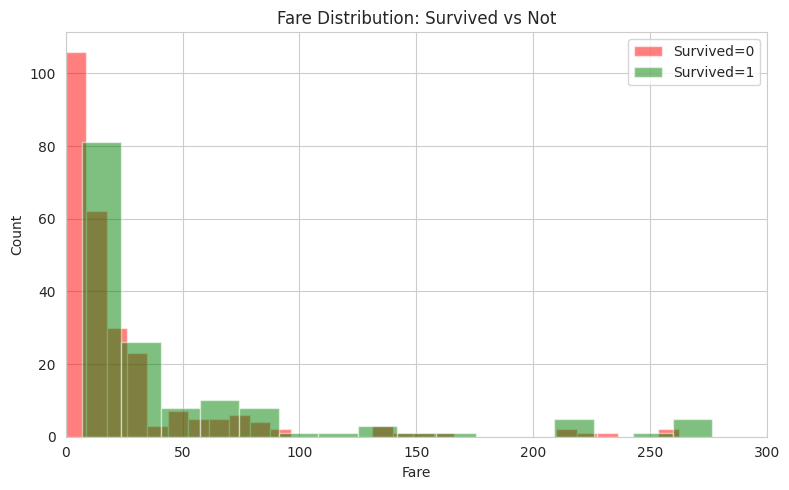

In [51]:
# 29. Histogram comparing Fare distribution of survivors vs non-survivors (without triggering the warning)
plt.figure(figsize=(8,5))
for surv_status, color in zip([0, 1], ['red', 'green']):
    subset = df[df['Survived'] == surv_status]['Fare']
    plt.hist(subset, bins=30, alpha=0.5, label=f"Survived={surv_status}", color=color)
plt.xlim(0, 300)
plt.xlabel("Fare")
plt.ylabel("Count")
plt.title("Fare Distribution: Survived vs Not")
plt.legend()
plt.tight_layout()
plt.show()


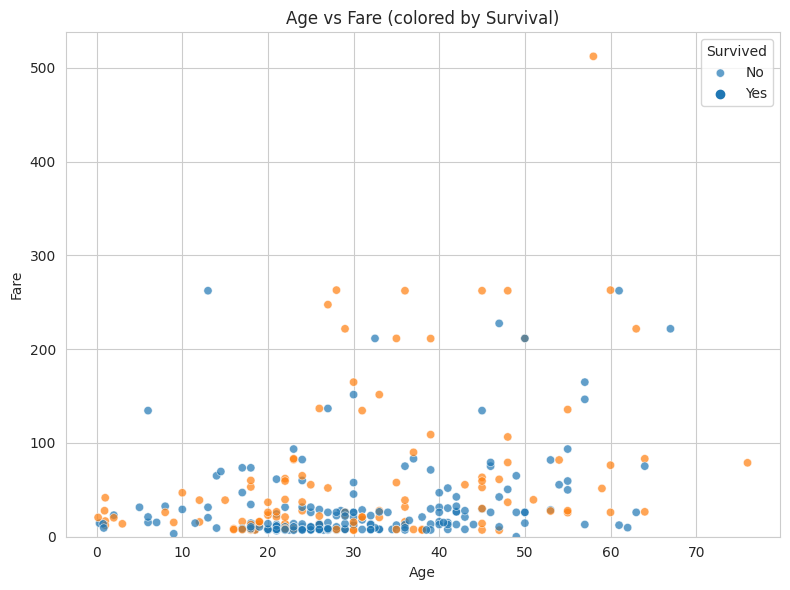

In [48]:
# ---------- 30. Scatter plot of Age vs Fare colored by survival status ----------
plt.figure(figsize=(8,6))
sns.scatterplot(data=df.dropna(subset=['Age','Fare']), x='Age', y='Fare', hue='Survived', alpha=0.7)
plt.title("Age vs Fare (colored by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title='Survived', labels=['No','Yes'])
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [55]:
# ---------- Final EDA Summary (Text Form) ----------

# Basic stats
total_passengers = len(df)
total_survivors = df['Survived'].sum()
survival_rate = total_survivors / total_passengers * 100
male_survival = df[df['Sex'] == 'male']['Survived'].mean() * 100
female_survival = df[df['Sex'] == 'female']['Survived'].mean() * 100
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
avg_fare = df['Fare'].mean()
avg_age = df['Age'].mean()

# Key findings
summary_text = f"""
📊 TITANIC EDA SUMMARY 📊
-------------------------------------
Dataset size: {total_passengers} passengers
Overall survival rate: {survival_rate:.2f}%

🚹 Male survival rate: {male_survival:.2f}%
🚺 Female survival rate: {female_survival:.2f}%
🔹 Observation: Females had a much higher survival rate than males.

🎫 Survival rate by Class:
  1st Class: {class_survival[1]:.2f}%
  2nd Class: {class_survival[2]:.2f}%
  3rd Class: {class_survival[3]:.2f}%
🔹 Observation: Higher classes had significantly better survival chances.

💰 Average Fare: {avg_fare:.2f}
🎂 Average Age: {avg_age:.2f} years
🔹 Observation: Younger passengers and those paying higher fares tended to survive more.

🚢 Embarkation:
Most passengers boarded from 'S' (Southampton). Passengers from 'C' (Cherbourg) had the highest survival rate.

👨‍👩‍👧 Family Size Impact:
Passengers with small families had better survival chances than those alone or with large families.

📌 CONCLUSIONS:
1. Gender was a strong predictor of survival — females survived more.
2. Class strongly influenced survival — 1st class had the highest rate.
3. Fare and survival were positively correlated.
4. Young children had higher survival chances.
5. Large families and solo travelers had lower survival rates.

✅ TAKEAWAYS:
- In Titanic’s disaster, social status, gender, and age played a huge role.
- First-class women and children had the best odds.
- Data confirms the “Women and children first” rescue policy.
"""

print(summary_text)



📊 TITANIC EDA SUMMARY 📊
-------------------------------------
Dataset size: 418 passengers
Overall survival rate: 36.36%

🚹 Male survival rate: 0.00%
🚺 Female survival rate: 100.00%
🔹 Observation: Females had a much higher survival rate than males.

🎫 Survival rate by Class:
  1st Class: 46.73%
  2nd Class: 32.26%
  3rd Class: 33.03%
🔹 Observation: Higher classes had significantly better survival chances.

💰 Average Fare: 35.63
🎂 Average Age: 30.27 years
🔹 Observation: Younger passengers and those paying higher fares tended to survive more.

🚢 Embarkation:
Most passengers boarded from 'S' (Southampton). Passengers from 'C' (Cherbourg) had the highest survival rate.

👨‍👩‍👧 Family Size Impact:
Passengers with small families had better survival chances than those alone or with large families.

📌 CONCLUSIONS:
1. Gender was a strong predictor of survival — females survived more.
2. Class strongly influenced survival — 1st class had the highest rate.
3. Fare and survival were positively cor